# Test Pipeline

Small notebook for testing the extracted line-mode pipeline on one SWORD reach selection.

In [36]:
import importlib

from pathlib import Path

import geopandas as gpd
import numpy as np

import supporting_metrics as sm
import supporting_geometry as sg
import supporting_boundaries as sb
import supporting_plotting as sp
import reach_concatenation as rc
import main_pipeline as mp

importlib.reload(sm)
importlib.reload(sg)
importlib.reload(sb)
importlib.reload(sp)
importlib.reload(rc)
importlib.reload(mp)


<module 'main_pipeline' from '/Users/6256481/Code/single_thread_channel_hierarchy/main_pipeline.py'>

In [2]:
cont = 'SA'

In [15]:
GPKG_PATH = Path(f"/Volumes/PhD/SWORD/v17c/sword_{cont}_v17c_reaches.parquet")
TARGET_CRS = "EPSG:3857"

if not GPKG_PATH.exists():
    raise FileNotFoundError(f"Update GPKG_PATH; file not found: {GPKG_PATH}")

df = gpd.read_parquet(GPKG_PATH)
df = df.to_crs('EPSG:3857')
df.shape, df.crs

((42159, 113),
 <Projected CRS: EPSG:3857>
 Name: WGS 84 / Pseudo-Mercator
 Axis Info [cartesian]:
 - X[east]: Easting (metre)
 - Y[north]: Northing (metre)
 Area of Use:
 - name: World between 85.06°S and 85.06°N.
 - bounds: (-180.0, -85.06, 180.0, 85.06)
 Coordinate Operation:
 - name: Popular Visualisation Pseudo-Mercator
 - method: Popular Visualisation Pseudo Mercator
 Datum: World Geodetic System 1984
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich)

In [16]:
r = df[(df["main_path_id"].isin([6000152]))]
merged = rc.merge_mainpaths(r)
display(merged)
merged = merged['line'].iloc[0]

100%|██████████| 1/1 [00:00<00:00,  4.89it/s]


,main_path_id,line,is_multilinestring,reach_ids,input_geom_length,merged_geom_length,length_removed,length_loss_frac
0,6000152,"LINESTRING (-7356936.372781 -1230777.13243, -7...",False,"[62266500011, 62266500021, 62266500031, 622665...",1.286912e+06,1.286912e+06,0.000002,1.795289e-12


In [22]:
# merged = merge_paths_mainstem_only(reach)
reach = r
width_m = float(reach["width"].median())

print("reach rows:", len(reach))
print("median width:", round(width_m, 2))
print("merged geometry:", merged.geom_type)
print("merged length:", round(merged.length, 2))

reach rows: 99
median width: 384.0
merged geometry: LineString
merged length: 1286911.93


In [39]:
10**3

1000

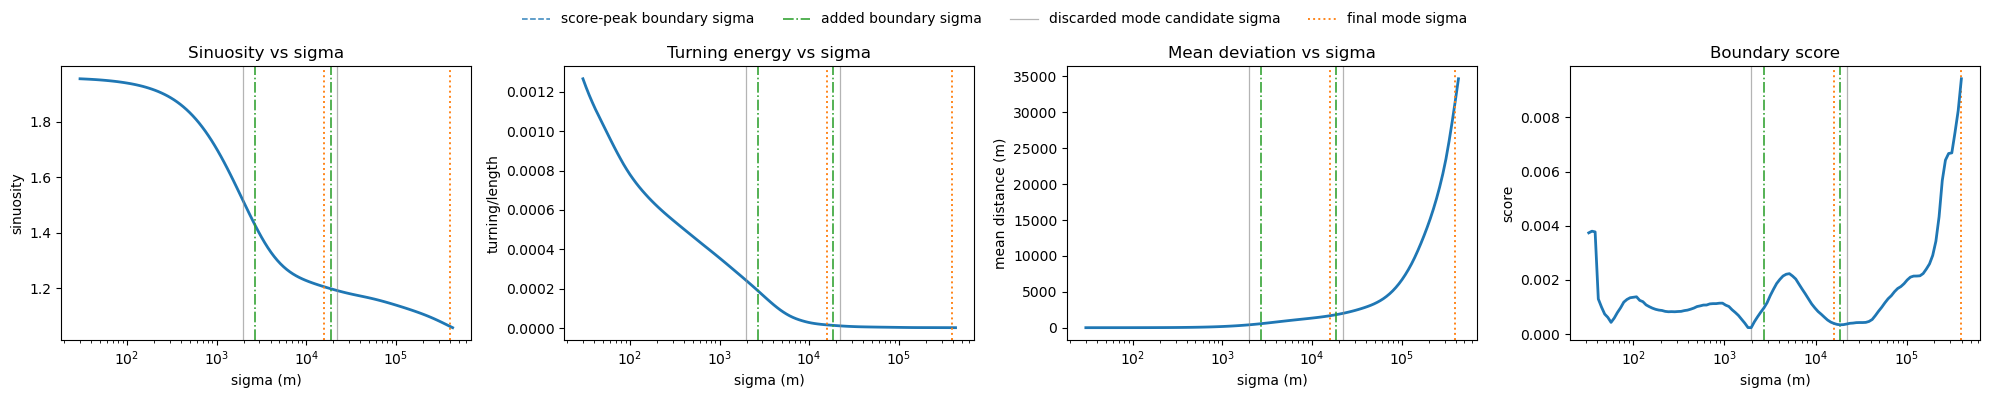

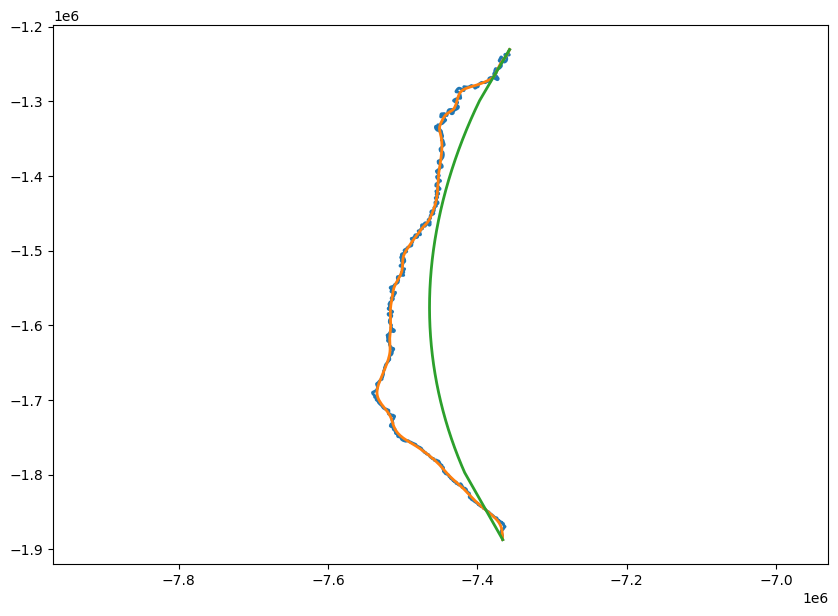

step_m: 15.0
boundary sigmas: [ 2706.72 18639.71]
mode sigmas: [ 15871.07 395608.22]
mid: {'mid_added': True, 'k_mid': 80, 'sigma_mid': 18639.714518947458, 'interval': (56, 119), 'base_mode_count': 2, 'try_mode_count': 3}
terminal: {'added_terminal': True, 'reason': 'accepted', 'tail_frac': 0.2, 'min_prom_frac': 0.35, 'min_sinu_drop': 0.03, 'min_dist_increase': 0.1, 'tail_start_score_idx': 94, 'tail_start_sigma': 62256.740894048344, 'tail_peak_score_idx': 117, 'prominence': 0.007194269224980068, 'prominence_global_max': 0.006098554611436972, 'prominence_ratio': 1.1796679186061954, 'sigma': 395608.2204900998, 'sinuosity_last': 1.2041977472801473, 'sinuosity_candidate': 1.0629361921114642, 'sinuosity_drop': 0.1412615551686831, 'distance_last': 1686.8558222200247, 'distance_candidate': 31610.94812615207, 'distance_ratio': 18.73956725273045, 'distance_sampling': {'sample_count': 4000, 'requested_count': None, 'requested_spacing': 300.0, 'actual_spacing': 321.6263580400428, 'strategy': 'spa

In [37]:
result = mp.extract_line_modes_auto(
    merged,
    width_m=width_m,
    make_plots=True,
    prune_dist_abs=width_m,
)

print("step_m:", result["step_m"])
print("boundary sigmas:", np.round(result["boundary_sigmas"], 2))
print("mode sigmas:", np.round(result["mode_sigmas"], 2))
print("mid:", result["mid_info"])
print("terminal:", result["terminal_info"])

for sigma, label in zip(result["mode_sigmas"], result["mode_labels"]):
    print(label, round(float(sigma), 2))

In [38]:
plot_labels = [
    f"{label} | sigma={sigma:.0f}m | sc={sc}"
    for sigma, label, sc in zip(
        result["mode_sigmas"],
        result["mode_labels"],
        result["curvature_sign_changes"],
    )
]

fig = sp.plot_modes_plotly(result["ls_equal"], result["modes"], labels=plot_labels, show=False)
fig

In [40]:
print(result["axis_fallback_used"])
print(result["peak_boundary_sigmas"])
print(result["added_boundary_sigmas"])


True
[]
[ 2706.72326594 18639.71451895]


In [41]:
import pandas as pd

# import pandas as pd
pd.DataFrame(result["boundary_diagnostics"]["candidates"])[
    ["sigma", "score", "prominence", "decision", "reason"]
]



,sigma,score,prominence,decision,reason
0,35.233372,0.003799,0.003368,rejected,insufficient local jump
1,108.588755,0.001375,NaN,rejected,below score percentile
2,262.945704,0.000827,NaN,rejected,below score percentile
3,951.764892,0.001140,NaN,rejected,below score percentile
4,5149.625613,0.002230,0.001995,rejected,below prominence percentile
5,30195.213636,0.000425,NaN,rejected,below score percentile


In [33]:
result["prune_diagnostics"]

{'settings': {'dist_abs': 384.0,
  'dist_w_frac': 0.3,
  'turn_frac_min': 0.15,
  'sc_frac_min': 0.2,
  'sinu_abs_min': 0.04,
  'dist_sample_spacing': 300.0,
  'dist_min_samples': 200,
  'dist_max_samples': 4000},
 'candidates': [{'candidate_index': 0,
   'sigma': 1962.356715501377,
   'comparison_basis': 'original',
   'distance': 408.02824085061474,
   'distance_threshold': 1152.0,
   'distance_pass': False,
   'turn_drop_frac': None,
   'sign_change_drop_frac': None,
   'sinuosity_drop_abs': None,
   'kept': False,
   'reason': 'failed distance gate',
   'distance_sampling': {'sample_count': 4000,
    'requested_count': None,
    'requested_spacing': 300.0,
    'actual_spacing': 321.6263580400428,
    'strategy': 'spacing_capped',
    'min_samples': 200,
    'max_samples': 4000}},
  {'candidate_index': 1,
   'sigma': 15871.073631037598,
   'comparison_basis': 'original',
   'distance': 1686.8558222200247,
   'distance_threshold': 1152.0,
   'distance_pass': True,
   'turn_drop_frac'

In [32]:
result['mode_sigmas'] / result['width_m']

array([  41.33092091, 1030.22974086])